<a href="https://colab.research.google.com/github/isil-ada/cifar10-multi-CNN-benchmark/blob/main/notebook_04_model4_hybrid_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YZM304 Derin Öğrenme – Proje 2
## Model 4: Hibrit — CNN Özellik Çıkarımı + SVM
**Akış:**  
1. Model 2 (eğitilmiş CNN) → 512 boyutlu özellik vektörü çıkar  
2. Özellikleri `.npy` dosyasına kaydet  
3. SVM ile sınıflandır  
> **Ön koşul:** Önce `notebook_02` çalıştırılmış olmalı (`model2_best.pth` gerekli)

In [1]:
import torch, torch.nn as nn
import torchvision, torchvision.transforms as transforms
import numpy as np, matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import time

torch.manual_seed(42); np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 10
CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2023, 0.1994, 0.2010]
print(f'Cihaz: {DEVICE}')

Cihaz: cuda


In [2]:
# ── Veri (augmentation YOK — sabit özellik çıkarımı) ─────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])
train_set = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, 256, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_set,  256, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:03<00:00, 48.4MB/s]


In [3]:
# ── Model 2 Mimarisi (ağırlık yüklemek için tanımlanmalı) ─────────────────────
class LeNet5CIFARv2(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,5), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,5), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.5),
            nn.Linear(64*5*5, 512), nn.ReLU(True),
            nn.Dropout(0.3), nn.Linear(512, num_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

cnn = LeNet5CIFARv2(NUM_CLASSES).to(DEVICE)

try:
    cnn.load_state_dict(torch.load('model2_best.pth', map_location=DEVICE))
    print('model2_best.pth yüklendi.')
except FileNotFoundError:
    print('UYARI: model2_best.pth bulunamadı! Hızlı eğitim başlıyor (10 epoch)...')
    aug = transforms.Compose([transforms.RandomHorizontalFlip(),
                               transforms.RandomCrop(32,4),
                               transforms.ToTensor(),
                               transforms.Normalize(MEAN,STD)])
    aug_loader = torch.utils.data.DataLoader(
        torchvision.datasets.CIFAR10('./data',True,download=True,transform=aug),
        128, shuffle=True, num_workers=2)
    crit = nn.CrossEntropyLoss()
    opt  = torch.optim.Adam(cnn.parameters(), lr=0.001)
    cnn.train()
    for ep in range(10):
        for X,y in aug_loader:
            X,y = X.to(DEVICE),y.to(DEVICE)
            opt.zero_grad(); loss=crit(cnn(X),y); loss.backward(); opt.step()
        print(f'  Epoch {ep+1}/10')
    torch.save(cnn.state_dict(),'model2_best.pth')
    print('Hızlı eğitim tamamlandı.')

UYARI: model2_best.pth bulunamadı! Hızlı eğitim başlıyor (10 epoch)...
  Epoch 1/10
  Epoch 2/10
  Epoch 3/10
  Epoch 4/10
  Epoch 5/10
  Epoch 6/10
  Epoch 7/10
  Epoch 8/10
  Epoch 9/10
  Epoch 10/10
Hızlı eğitim tamamlandı.


In [4]:
# ── Özellik Çıkarıcı: features + FC1 (512 boyut) ──────────────────────────────
# CNN'in son sınıflandırıcı katmanı (Linear 512→10) ÇIKARILIR
# features → Flatten → Dropout(0) → Linear(1600→512) → ReLU → 512 boyutlu vektör

cnn.eval()
feature_extractor = nn.Sequential(
    cnn.features,               # Conv blokları
    nn.Flatten(),
    cnn.classifier[2],          # Linear(1600→512)
    cnn.classifier[3],          # ReLU
).to(DEVICE)
feature_extractor.eval()

@torch.no_grad()
def extract_features(loader, extractor, dev):
    feats, lbls = [], []
    for X, y in loader:
        f = extractor(X.to(dev)).cpu().numpy()
        feats.append(f); lbls.extend(y.numpy())
    return np.vstack(feats), np.array(lbls)

print('Eğitim özellikleri çıkarılıyor...')
X_train, y_train = extract_features(train_loader, feature_extractor, DEVICE)
print('Test özellikleri çıkarılıyor...')
X_test,  y_test  = extract_features(test_loader,  feature_extractor, DEVICE)

Eğitim özellikleri çıkarılıyor...
Test özellikleri çıkarılıyor...


In [5]:
# ── Özellik Seti Boyut Raporu ──────────────────────────────────────────────────
print('='*45)
print(f'X_train boyutu  : {X_train.shape}')   # (50000, 512)
print(f'y_train uzunluğu: {y_train.shape}')   # (50000,)
print(f'X_test  boyutu  : {X_test.shape}')    # (10000, 512)
print(f'y_test  uzunluğu: {y_test.shape}')    # (10000,)
print(f'Özellik boyutu  : {X_train.shape[1]}')
print('='*45)

# .npy Kaydet
np.save('features_train.npy', X_train)
np.save('labels_train.npy',   y_train)
np.save('features_test.npy',  X_test)
np.save('labels_test.npy',    y_test)
print('\nDosyalar kaydedildi: features_train.npy, labels_train.npy, features_test.npy, labels_test.npy')

X_train boyutu  : (50000, 512)
y_train uzunluğu: (50000,)
X_test  boyutu  : (10000, 512)
y_test  uzunluğu: (10000,)
Özellik boyutu  : 512

Dosyalar kaydedildi: features_train.npy, labels_train.npy, features_test.npy, labels_test.npy


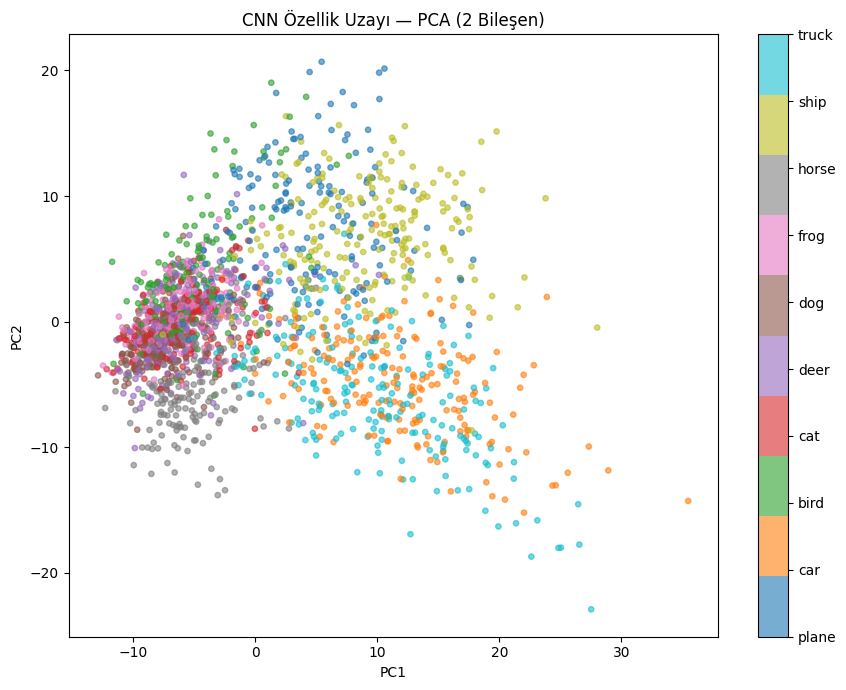

In [6]:
# ── Özellik Dağılımı Görselleştirme ──────────────────────────────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_vis = pca.fit_transform(X_test[:2000])
y_vis = y_test[:2000]

fig, ax = plt.subplots(figsize=(9,7))
scatter = ax.scatter(X_vis[:,0], X_vis[:,1], c=y_vis,
                     cmap='tab10', alpha=0.6, s=15)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(10))
cbar.ax.set_yticklabels(CLASSES)
ax.set(title='CNN Özellik Uzayı — PCA (2 Bileşen)', xlabel='PC1', ylabel='PC2')
plt.tight_layout(); plt.savefig('feature_pca.png', dpi=150); plt.show()

In [7]:
# ── SVM Sınıflandırıcı ────────────────────────────────────────────────────────
# StandardScaler: SVM kernel mesafe tabanlı → ölçek normalizasyonu kritik
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

print('SVM eğitimi başlıyor (RBF kernel, C=10)...')
print('Not: SVM GPU desteklemez, CPU üzerinde çalışır (~10-20 dk)')
t0  = time.time()
svm = SVC(kernel='rbf', C=10, gamma='scale',
          decision_function_shape='ovr', random_state=42)
svm.fit(X_tr_sc, y_train)
print(f'SVM eğitim süresi: {time.time()-t0:.1f}s')

SVM eğitimi başlıyor (RBF kernel, C=10)...
Not: SVM GPU desteklemez, CPU üzerinde çalışır (~10-20 dk)
SVM eğitim süresi: 337.3s


=== Sınıflandırma Raporu — Model 4 (CNN+SVM) ===
              precision    recall  f1-score   support

       plane       0.75      0.80      0.77      1000
         car       0.87      0.88      0.88      1000
        bird       0.68      0.65      0.66      1000
         cat       0.57      0.60      0.58      1000
        deer       0.72      0.73      0.72      1000
         dog       0.67      0.65      0.66      1000
        frog       0.82      0.82      0.82      1000
       horse       0.80      0.76      0.78      1000
        ship       0.87      0.85      0.86      1000
       truck       0.85      0.85      0.85      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.76     10000
weighted avg       0.76      0.76      0.76     10000



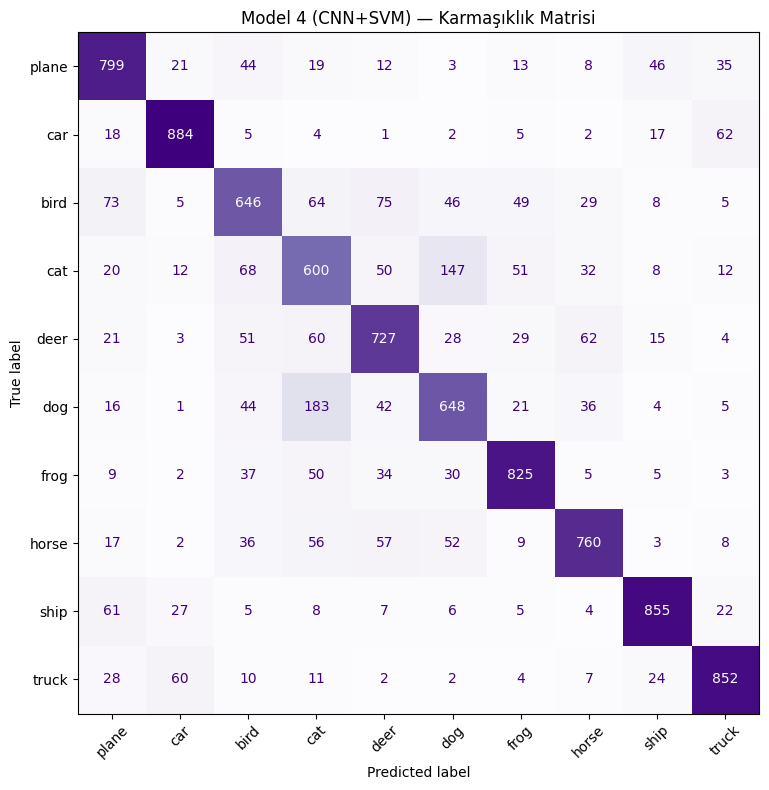


Model 4 (CNN+SVM) Test Doğruluğu: 75.96%


In [8]:
svm_preds = svm.predict(X_te_sc)
svm_acc   = (svm_preds == y_test).mean() * 100

print('=== Sınıflandırma Raporu — Model 4 (CNN+SVM) ===')
print(classification_report(y_test, svm_preds, target_names=CLASSES))

cm = confusion_matrix(y_test, svm_preds)
fig, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax,cmap='Purples',colorbar=False,xticks_rotation=45)
ax.set_title('Model 4 (CNN+SVM) — Karmaşıklık Matrisi')
plt.tight_layout(); plt.savefig('model4_confusion.png', dpi=150); plt.show()

np.save('model4_results.npy', {'svm_acc': svm_acc, 'preds': svm_preds})
print(f'\nModel 4 (CNN+SVM) Test Doğruluğu: {svm_acc:.2f}%')